# EMNIST — Custom Training Loop avec Keras + PyTorch backend
Architecture CNN entraînée sur le split `byclass` (62 classes : chiffres + lettres majuscules/minuscules).  
Boucle d'entraînement bas-niveau inspirée du guide officiel Keras.

### Améliorations v2
- `kernel_size=3` partout (3×3 standard pour 28×28)
- Double Dropout (0.4 + 0.3) pour mieux régulariser
- `GlobalAveragePooling2D` à la place de Flatten → moins de paramètres
- LR Scheduler `ReduceLROnPlateau` pour affiner la convergence
- Augmentation de données enrichie (shear + translate)
- Early stopping avec patience améliorée

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras
import numpy as np
from torchvision.datasets import EMNIST
from torchvision.transforms import v2
from torch.utils.data import DataLoader

print(f"Keras version  : {keras.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device         : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Keras version  : 3.14.0
PyTorch version: 2.11.0+cu126
Device         : cuda


## 1. Chargement & transformations EMNIST

In [2]:
# --- Transformations ---
# EMNIST est stocké transposé → flip + rotation pour corriger l'orientation
tran_train = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),                        # correction EMNIST
    v2.RandomRotation(degrees=(90, 90)),                    # correction EMNIST
    v2.RandomRotation(degrees=(-15, 15)),                   # augmentation : rotation
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),       # augmentation : décalage
    v2.RandomAffine(degrees=0, shear=10),                   # augmentation : cisaillement
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

tran_test = v2.Compose([
    v2.RandomHorizontalFlip(p=1.0),
    v2.RandomRotation(degrees=(90, 90)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

# --- Datasets (byclass = 62 classes) ---
train_data = EMNIST(root="data", split="byclass", train=True,  transform=tran_train, download=True)
test_data  = EMNIST(root="data", split="byclass", train=False, transform=tran_test,  download=True)

print(f"Train samples : {len(train_data):,}")
print(f"Test  samples : {len(test_data):,}")
print(f"Nb classes    : {len(train_data.classes)}")

Train samples : 697,932
Test  samples : 116,323
Nb classes    : 62


In [3]:
BATCH_SIZE = 64

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Batches train : {len(train_loader):,}")
print(f"Batches test  : {len(test_loader):,}")

Batches train : 10,906
Batches test  : 1,818


## 2. Visualisation rapide

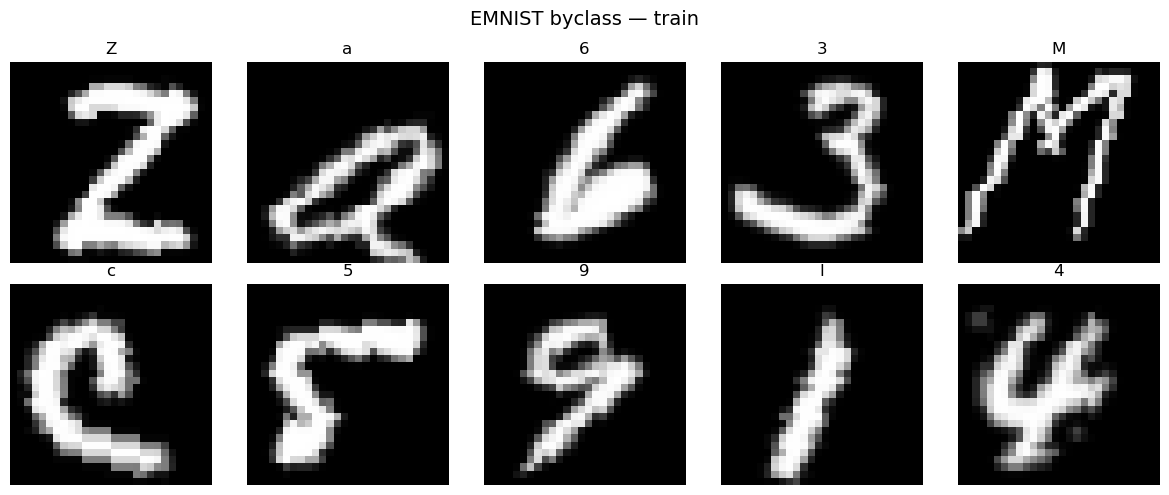

In [4]:
import matplotlib.pyplot as plt

def show_images(dataset, main_title="EMNIST byclass", n=10):
    fig, axes = plt.subplots(2, n // 2, figsize=(12, 5))
    fig.suptitle(main_title, fontsize=14)
    for ax, (img, label) in zip(axes.flat, dataset):
        ax.imshow(img.permute(1, 2, 0).squeeze(), cmap="gray")
        ax.set_title(dataset.classes[label])
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_images(train_data, main_title="EMNIST byclass — train")

## 3. Modèle CNN avec Keras

Architecture **4 blocs convolutifs** avec les améliorations suivantes par rapport à la v1 :

- `kernel_size=3` partout : taille standard pour des images 28×28, évite de lisser des détails fins
- `SpatialDropout2D` après chaque bloc conv : désactive des feature maps entières plutôt que des pixels
  individuels, ce qui est plus efficace pour régulariser des CNN
- `GlobalAveragePooling2D` remplace `Flatten` : réduit la sortie convolutive à 128 valeurs
  au lieu de 6272, ce qui diminue massivement le nombre de paramètres et limite l'overfitting
- Double `Dropout` en tête (0.4 + 0.3) et régularisation L2 sur la couche dense
- Tête dense réduite : 128 → 62 logits


In [5]:
NUM_CLASSES = 62  # byclass : 10 chiffres + 26 maj + 26 min

class EMNISTModel(keras.Model):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bloc 1
        self.conv1    = keras.layers.Conv2D(32, kernel_size=3, padding="same", activation="relu")
        self.bn1      = keras.layers.BatchNormalization()
        self.sdrop1   = keras.layers.SpatialDropout2D(0.1)   # désactive des canaux entiers pour régulariser les feature maps
        self.pool1    = keras.layers.MaxPooling2D(2)          # 28 → 14

        # Bloc 2
        self.conv2    = keras.layers.Conv2D(64, kernel_size=3, padding="same", activation="relu")
        self.bn2      = keras.layers.BatchNormalization()
        self.sdrop2   = keras.layers.SpatialDropout2D(0.1)
        self.pool2    = keras.layers.MaxPooling2D(2)          # 14 → 7

        # Bloc 3
        self.conv3    = keras.layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")
        self.bn3      = keras.layers.BatchNormalization()
        self.sdrop3   = keras.layers.SpatialDropout2D(0.1)

        # Bloc 4 — pas de MaxPool : la carte spatiale est déjà à 7×7 après pool2, un pooling supplémentaire détruirait l'information
        self.conv4    = keras.layers.Conv2D(256, kernel_size=3, padding="same", activation="relu")
        self.bn4      = keras.layers.BatchNormalization()

        self.gap      = keras.layers.GlobalAveragePooling2D()

        # Tête de classification : GAP → Dropout(0.4) → Dense(128, L2) → Dropout(0.3) → logits
        self.dropout1 = keras.layers.Dropout(0.4)
        self.fc1      = keras.layers.Dense(128, activation="relu",
                            kernel_regularizer=keras.regularizers.L2(1e-4))  # pénalise les grands poids pour limiter l'overfitting
        self.dropout2 = keras.layers.Dropout(0.3)
        self.fc2      = keras.layers.Dense(num_classes)

    def call(self, x, training=False):
        x = keras.ops.transpose(x, axes=(0, 2, 3, 1))

        x = self.sdrop1(self.pool1(self.bn1(self.conv1(x), training=training)), training=training)
        x = self.sdrop2(self.pool2(self.bn2(self.conv2(x), training=training)), training=training)
        x = self.sdrop3(self.bn3(self.conv3(x), training=training), training=training)
        x = self.bn4(self.conv4(x), training=training)

        x = self.gap(x)
        x = self.dropout1(x, training=training)
        x = self.fc1(x)
        x = self.dropout2(x, training=training)
        return self.fc2(x)

model = EMNISTModel()

# Build pour afficher le summary
dummy = torch.zeros(1, 1, 28, 28)
_ = model(dummy)
model.summary()


Model: "emnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 28, 28, 32)        │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 28, 28, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ ?                      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 14, 14, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 14, 14, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ ?                      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 7, 7, 128)         │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 7, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ ?                      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 7, 7, 256)         │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 7, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 62)                │         7,998 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,654 (1.64 MB)

 Trainable params: 429,694 (1.64 MB)

 Non-trainable params: 960 (3.75 KB)

## 4. Boucle d'entraînement custom

Même structure que la v1, avec deux ajouts pour améliorer la convergence :

- **`ReduceLROnPlateau`** : divise le learning rate par 2 si la `val_acc` ne progresse plus
  pendant 2 epochs. Permet d'affiner les poids sans relancer manuellement l'entraînement.
- **`PATIENCE = 5`** (au lieu de 3) : laisse plus de temps au scheduler LR d'agir
  avant de déclencher l'early stopping.
- **Label smoothing** : remplace la cible one-hot dure (0/1) par une distribution lissée
  (ε=0.1), ce qui réduit la confiance excessive du modèle et améliore la généralisation.


In [ ]:
# --- Hyperparamètres ---
NUM_EPOCHS    = 15
LEARNING_RATE = 1e-3
LOG_EVERY     = 500

# --- Optimizer Keras ---
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# LR Scheduler PyTorch wrappé autour d'un optimizer factice
# Keras ne dispose pas de ReduceLROnPlateau natif, donc on utilise le scheduler
# PyTorch pour suivre la val_acc et ajuster le LR de l'optimizer Keras manuellement
_torch_optim = torch.optim.Adam([torch.zeros(1, requires_grad=True)], lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    _torch_optim,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

# Implémentation manuelle du label smoothing en PyTorch
# Keras SparseCategoricalCrossentropy ne supporte pas le label_smoothing avec from_logits=True et des entiers
def smooth_cross_entropy(logits, labels, smoothing=0.1):
    log_probs  = torch.nn.functional.log_softmax(logits, dim=-1)
    nll_loss   = torch.nn.functional.nll_loss(log_probs, labels)
    smooth_loss = -log_probs.mean()
    return (1.0 - smoothing) * nll_loss + smoothing * smooth_loss

# --- Métriques Keras ---
train_acc_metric = keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = keras.metrics.SparseCategoricalAccuracy()

# --- Early stopping ---
best_val_acc     = 0.0
patience_counter = 0
PATIENCE         = 5

history = {"train_loss": [], "train_acc": [], "val_acc": [], "lr": []}

# =====================================================================
#  BOUCLE PRINCIPALE
# =====================================================================
for epoch in range(NUM_EPOCHS):
    current_lr = float(optimizer.learning_rate)
    print(f"\n{'='*65}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}  |  LR: {current_lr:.2e}")
    print(f"{'='*65}")

    running_loss = 0.0

    # ── Phase d'entraînement ──────────────────────────────────────────────
    for step, (images, labels) in enumerate(train_loader):

        # Forward pass — training=True active BatchNorm et SpatialDropout
        logits = model(images, training=True)

        # Calcul de la loss avec label smoothing (labels entiers, pas de one-hot)
        loss = smooth_cross_entropy(logits, labels.to(logits.device), smoothing=0.1)

        # Backward pass via PyTorch autograd
        model.zero_grad()  # efface les gradients du batch précédent
        trainable_weights = list(model.trainable_weights)
        loss.backward()
        gradients = [v.value.grad for v in trainable_weights]

        # Mise à jour des poids via l'optimizer Keras (dans no_grad pour ne pas tracer les updates)
        with torch.no_grad():
            optimizer.apply(gradients, trainable_weights)

        # Mise à jour des métriques d'accuracy
        train_acc_metric.update_state(labels, logits)
        running_loss += loss.detach().item()

        if step % LOG_EVERY == 0:
            avg_loss = running_loss / (step + 1)
            print(f"  Step {step:>5} | Loss: {avg_loss:.4f} | "
                  f"Acc: {float(train_acc_metric.result()):.4f}")

    # Résultats epoch train
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = float(train_acc_metric.result())
    train_acc_metric.reset_state()
    history["train_loss"].append(epoch_loss)
    history["train_acc"].append(epoch_acc)
    history["lr"].append(current_lr)
    print(f"\n→ Train  | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # ── Phase de validation (pas de gradient, training=False) ─────────────
    for images, labels in test_loader:
        val_logits = model(images, training=False)
        val_acc_metric.update_state(labels, val_logits)

    val_acc = float(val_acc_metric.result())
    val_acc_metric.reset_state()
    history["val_acc"].append(val_acc)
    print(f"→ Val    | Acc: {val_acc:.4f}")

    # ── Mise à jour du LR via le scheduler ───────────────────────────────
    # Le scheduler surveille la val_acc et réduit le LR si elle stagne
    # On reporte ensuite la nouvelle valeur dans l'optimizer Keras
    scheduler.step(val_acc)
    new_lr = _torch_optim.param_groups[0]['lr']
    if new_lr != current_lr:
        optimizer.learning_rate.assign(new_lr)
        print(f" LR réduit : {current_lr:.2e} → {new_lr:.2e}")

    # ── Sauvegarde du meilleur checkpoint + early stopping ────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_weights("best_emnist_model.weights.h5")
        print(f"  Meilleur modèle sauvegardé (val_acc={best_val_acc:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  Pas d'amélioration ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(" Early stopping déclenché.")
            break

print(f"\nMeilleure val_acc : {best_val_acc:.4f}")



Epoch 1/15  |  LR: 1.00e-03
  Step     0 | Loss: 4.1522 | Acc: 0.0312
  Step   500 | Loss: 2.2154 | Acc: 0.5489
  Step  1000 | Loss: 1.9064 | Acc: 0.6364
  Step  1500 | Loss: 1.7612 | Acc: 0.6795
  Step  2000 | Loss: 1.6746 | Acc: 0.7050
  Step  2500 | Loss: 1.6159 | Acc: 0.7225
  Step  3000 | Loss: 1.5731 | Acc: 0.7353
  Step  3500 | Loss: 1.5401 | Acc: 0.7447
  Step  4000 | Loss: 1.5121 | Acc: 0.7529
  Step  4500 | Loss: 1.4900 | Acc: 0.7591
  Step  5000 | Loss: 1.4712 | Acc: 0.7644
  Step  5500 | Loss: 1.4545 | Acc: 0.7691
  Step  6000 | Loss: 1.4409 | Acc: 0.7729
  Step  6500 | Loss: 1.4290 | Acc: 0.7762
  Step  7000 | Loss: 1.4181 | Acc: 0.7792
  Step  7500 | Loss: 1.4083 | Acc: 0.7819
  Step  8000 | Loss: 1.3988 | Acc: 0.7847
  Step  8500 | Loss: 1.3909 | Acc: 0.7869
  Step  9000 | Loss: 1.3834 | Acc: 0.7891
  Step  9500 | Loss: 1.3768 | Acc: 0.7908
  Step 10000 | Loss: 1.3702 | Acc: 0.7926
  Step 10500 | Loss: 1.3640 | Acc: 0.7945

→ Train  | Loss: 1.3592 | Acc: 0.7959
→ Val   

KeyboardInterrupt: 

## 5. Courbes d'entraînement

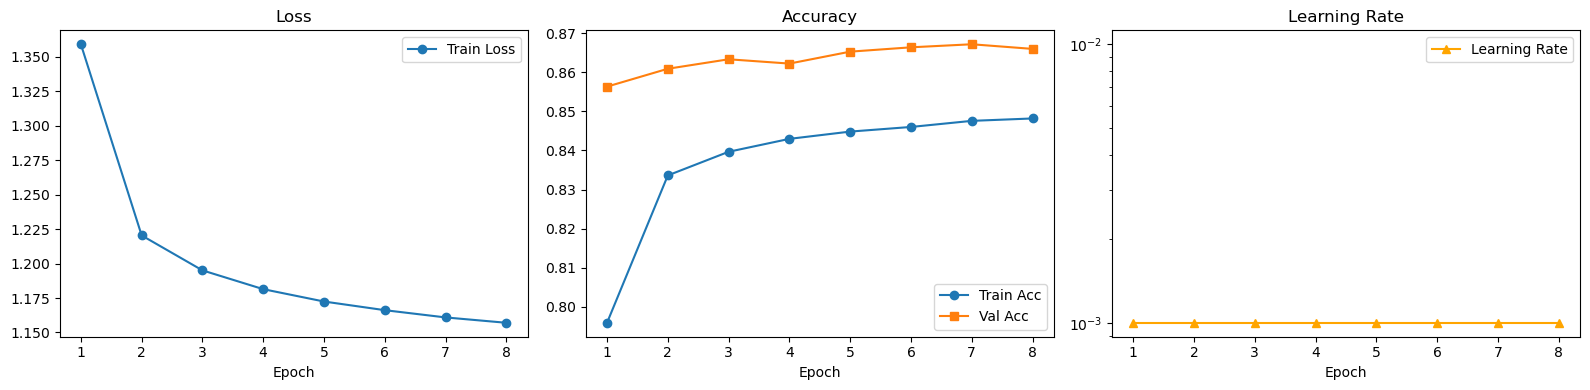

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_acc"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="Train Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   marker="s", label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs_range, history["lr"], marker="^", color="orange", label="Learning Rate")
axes[2].set_title("Learning Rate")
axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Évaluation finale (meilleur checkpoint)

In [12]:
# Rechargement du meilleur checkpoint avant l'évaluation finale
# (les poids courants peuvent venir d'une epoch moins bonne si l'early stopping s'est déclenché)
model.load_weights("best_emnist_model.weights.h5")

eval_metric = keras.metrics.SparseCategoricalAccuracy()

for images, labels in test_loader:
    logits = model(images, training=False)
    eval_metric.update_state(labels, logits)

final_acc = float(eval_metric.result())
print(f"Accuracy finale sur le test set : {final_acc * 100:.2f}%")


Accuracy finale sur le test set : 86.72%


## 7. Visualiser les prédictions

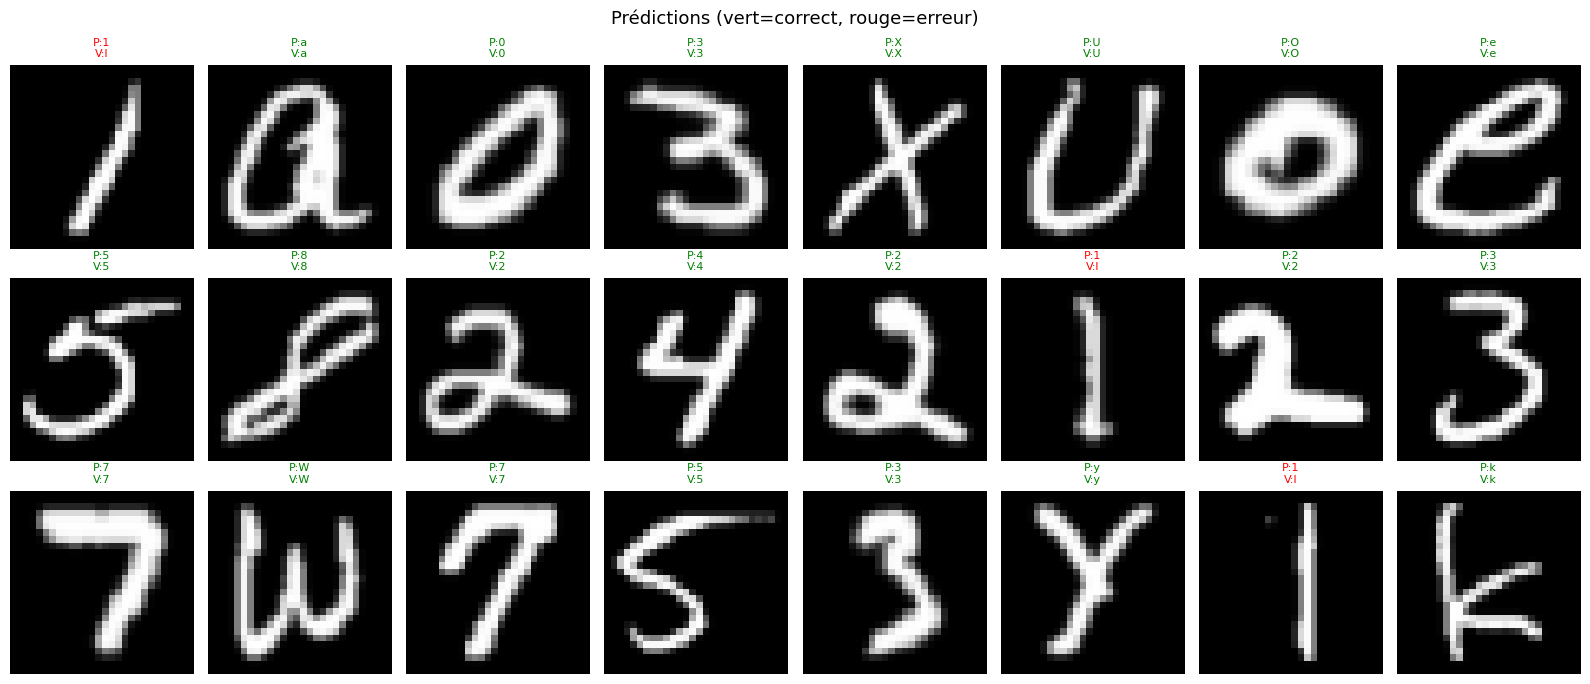

In [13]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

classes = test_data.classes

images, labels = next(iter(test_loader))

with torch.no_grad():
    logits = model(images, training=False)
    probs  = F.softmax(torch.tensor(logits.cpu().numpy()), dim=1)
    preds  = probs.argmax(dim=1)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for ax, img, pred, true in zip(axes.flat, images.cpu(), preds, labels):
    ax.imshow(img.permute(1, 2, 0).squeeze(), cmap="gray")
    color = "green" if pred.item() == true.item() else "red"
    ax.set_title(f"P:{classes[pred]}\nV:{classes[true]}", color=color, fontsize=8)
    ax.axis("off")

plt.suptitle("Prédictions (vert=correct, rouge=erreur)", fontsize=13)
plt.tight_layout()
plt.show()